In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import NaviLib as nl

from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight


In [2]:
PATH = r"C:\Users\navid\OneDrive\دسکتاپ\projects\9)Golden Treatment Window Prediction\data\sepsis_icu_synthetic.csv"

data = pd.read_csv(PATH)

In [3]:
data.shape

(5000, 77)

In [4]:
data.columns

Index(['subject_id', 'age', 'gender', 'weight_kg', 'height_cm', 'bmi',
       'ethnicity', 'insurance', 'hr_mean', 'hr_max', 'hr_min', 'hr_std',
       'sbp_mean', 'sbp_max', 'sbp_min', 'sbp_std', 'dbp_mean', 'dbp_max',
       'dbp_min', 'dbp_std', 'map_mean', 'temp_celsius_mean',
       'temp_celsius_max', 'temp_celsius_min', 'temp_celsius_std', 'spo2_mean',
       'spo2_min', 'spo2_max', 'spo2_std', 'respiratory_rate_mean',
       'respiratory_rate_max', 'respiratory_rate_min', 'respiratory_rate_std',
       'wbc', 'lactate_mmol', 'creatinine', 'platelet_count',
       'bilirubin_total', 'glucose', 'ph_arterial', 'pao2_fio2_ratio', 'inr',
       'sodium', 'potassium', 'chloride', 'bicarbonate', 'hematocrit',
       'hemoglobin', 'diabetes', 'hypertension', 'chf', 'copd',
       'chronic_kidney_disease', 'liver_disease', 'immunosuppression', 'cad',
       'atrial_fibrillation', 'cancer_active', 'vasopressors_flag',
       'mechanical_ventilation', 'fio2_percent', 'antibiotics_24h',
  

In [5]:
train , test = train_test_split(
    data , test_size=0.2 , random_state=42 , stratify=data['sepsis_label'])

In [6]:
print(f'Train shape = {train.shape}')
print(f'Test shape = {test.shape}')

Train shape = (4000, 77)
Test shape = (1000, 77)


In [7]:
train.head()

,subject_id,age,gender,weight_kg,height_cm,bmi,ethnicity,insurance,hr_mean,hr_max,...,apache_iv,qsofa,sirs_criteria,gcs_total,icu_los_hours,hospital_admit_source,icu_admit_time_hour,day_of_week,readmission_30day,sepsis_label
3249,74035,37,F,76.5,186.8,21.9,White,Private,100.6,118.9,...,21.8,1,1,8,12.2,Direct,0,2,0,0
4652,78568,65,F,46.2,179.1,14.4,White,Medicare,108.4,120.1,...,30.4,1,1,7,36.7,ED,21,6,0,0
1364,49825,82,F,94.5,182.2,28.4,White,Medicare,76.4,95.5,...,36.8,1,0,6,62.4,ED,16,5,0,0
1625,32581,81,M,76.0,165.2,27.8,White,Medicare,98.0,117.2,...,46.9,1,1,7,67.5,Transfer,16,7,0,0
712,43732,56,M,86.8,164.1,32.2,Asian,Private,174.0,99.5,...,31.6,1,1,11,41.8,Direct,16,4,0,0


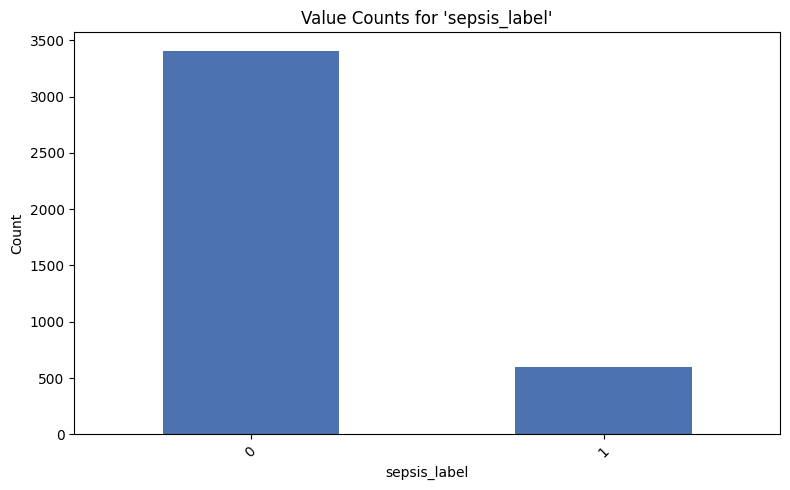

sepsis_label
0    3400
1     600
Name: count, dtype: int64

In [8]:
nl.value_counts_plot(df = train , column = 'sepsis_label')

In [9]:
train_num = train.select_dtypes(
    include=['int64', 'float64', 'int32', 'float32', 'bool']
)

complet_report , general_report , _ = nl.xgboost_feature_analysis(
    df = train_num,
    target = 'sepsis_label',
    problem_type = 'classification',
    random_state = 42,
    top_k = 40
)

⚠ Warning: Missing values detected. Filling with 0 for XGBoost.


In [10]:
complet_report[:30]

,feature,gain_percent,perm_percent,combined_score
0,pao2_fio2_ratio,39.741533,100.0,63.844920
1,creatinine,24.532185,0.0,14.719311
2,lactate_mmol,21.873516,0.0,13.124110
3,sofa_score,4.798607,0.0,2.879164
4,spo2_mean,4.101178,0.0,2.460707
5,fluids_ml_24h,1.455136,0.0,0.873082
6,apache_iv,1.252524,0.0,0.751514
7,sirs_criteria,0.606410,0.0,0.363846
8,respiratory_rate_mean,0.494777,0.0,0.296866
9,respiratory_rate_min,0.428601,0.0,0.257161


In [11]:
train.select_dtypes(include=['object' , 'str'])

,gender,ethnicity,insurance,hospital_admit_source
3249,F,White,Private,Direct
4652,F,White,Medicare,ED
1364,F,White,Medicare,ED
1625,M,White,Medicare,Transfer
712,M,Asian,Private,Direct
...,...,...,...,...
3402,M,White,Medicare,Transfer
1390,M,White,Medicaid,ED
3095,M,White,Medicaid,OR
4805,F,White,Medicare,OR


In [12]:
important_features = [
    'pao2_fio2_ratio',
    'creatinine',
    'lactate_mmol',
    'sofa_score',
    'spo2_mean',
    'fluids_ml_24h',
    'apache_iv',
    'sirs_criteria',
    'respiratory_rate_mean',
    'respiratory_rate_min',
    'bicarbonate',
    'ph_arterial',
    'temp_celsius_min',
    'sbp_min',
    'gender',
    'ethnicity',
    'insurance',
    'hospital_admit_source'
]

In [13]:
train = train[important_features + ['sepsis_label']]

In [14]:
train.head()

,pao2_fio2_ratio,creatinine,lactate_mmol,sofa_score,spo2_mean,fluids_ml_24h,apache_iv,sirs_criteria,respiratory_rate_mean,respiratory_rate_min,bicarbonate,ph_arterial,temp_celsius_min,sbp_min,gender,ethnicity,insurance,hospital_admit_source,sepsis_label
3249,99.0,1.70,1.08,7,99.0,1208.0,21.8,1,20.0,16.0,NaN,7.423,36.6,101.6,F,White,Private,Direct,0
4652,98.1,1.75,0.85,7,98.1,1765.0,30.4,1,18.0,14.0,23.8,NaN,37.6,98.8,F,White,Medicare,ED,0
1364,98.7,2.27,0.81,9,98.7,1344.0,36.8,0,14.0,12.0,25.6,7.428,37.8,97.1,F,White,Medicare,ED,0
1625,95.0,2.63,0.79,9,95.0,1226.0,46.9,1,13.0,9.0,25.3,7.420,36.9,112.7,M,White,Medicare,Transfer,0
712,98.4,2.18,0.69,8,98.4,1423.0,31.6,1,14.0,10.0,26.6,7.414,36.9,116.5,M,Asian,Private,Direct,0


#### sepsis_label

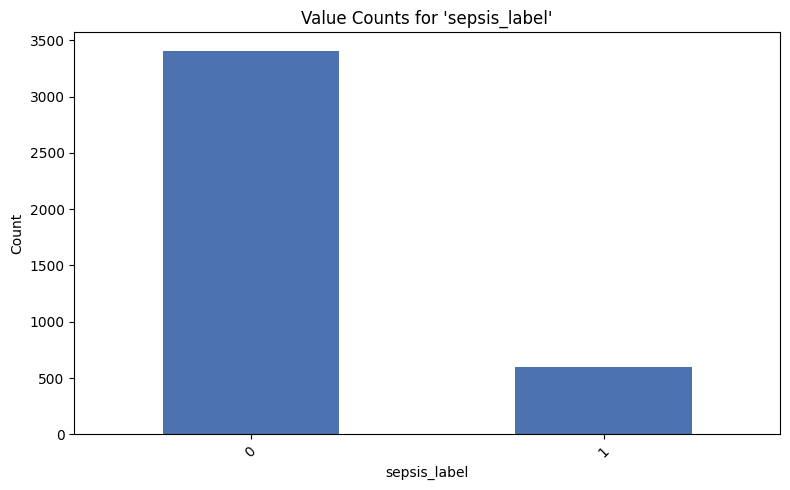

sepsis_label
0    3400
1     600
Name: count, dtype: int64

In [15]:
nl.value_counts_plot(df = train , column = 'sepsis_label')

In [16]:
nl.missing_report(df = train , column = 'sepsis_label')

{'column': 'sepsis_label',
 'dtype': 'int64',
 'total_rows': 4000,
 'missing_count': 0,
 'missing_percent': np.float64(0.0)}

In [17]:
nl.missing_report(df = test , column = 'sepsis_label')

{'column': 'sepsis_label',
 'dtype': 'int64',
 'total_rows': 1000,
 'missing_count': 0,
 'missing_percent': np.float64(0.0)}

In [18]:
for column in train.columns:
    report = nl.missing_report(df = train , column = column)
    print(f'For {column} :{report}')
    print('*'*80)
    print('\n')

For pao2_fio2_ratio :{'column': 'pao2_fio2_ratio', 'dtype': 'float64', 'total_rows': 4000, 'missing_count': 0, 'missing_percent': np.float64(0.0)}
********************************************************************************


For creatinine :{'column': 'creatinine', 'dtype': 'float64', 'total_rows': 4000, 'missing_count': 443, 'missing_percent': np.float64(11.08)}
********************************************************************************


For lactate_mmol :{'column': 'lactate_mmol', 'dtype': 'float64', 'total_rows': 4000, 'missing_count': 0, 'missing_percent': np.float64(0.0)}
********************************************************************************


For sofa_score :{'column': 'sofa_score', 'dtype': 'int64', 'total_rows': 4000, 'missing_count': 0, 'missing_percent': np.float64(0.0)}
********************************************************************************


For spo2_mean :{'column': 'spo2_mean', 'dtype': 'float64', 'total_rows': 4000, 'missing_count': 0, 'miss

In [19]:
for column in train.columns:
    report = nl.missing_report(df = test , column = column)
    print(f'For {column} :{report}')
    print('*'*80)
    print('\n')

For pao2_fio2_ratio :{'column': 'pao2_fio2_ratio', 'dtype': 'float64', 'total_rows': 1000, 'missing_count': 0, 'missing_percent': np.float64(0.0)}
********************************************************************************


For creatinine :{'column': 'creatinine', 'dtype': 'float64', 'total_rows': 1000, 'missing_count': 107, 'missing_percent': np.float64(10.7)}
********************************************************************************


For lactate_mmol :{'column': 'lactate_mmol', 'dtype': 'float64', 'total_rows': 1000, 'missing_count': 0, 'missing_percent': np.float64(0.0)}
********************************************************************************


For sofa_score :{'column': 'sofa_score', 'dtype': 'int64', 'total_rows': 1000, 'missing_count': 0, 'missing_percent': np.float64(0.0)}
********************************************************************************


For spo2_mean :{'column': 'spo2_mean', 'dtype': 'float64', 'total_rows': 1000, 'missing_count': 0, 'missi

#  Dataset Summary Report (Sepsis Prediction)

##  Objective
Binary classification task to predict `sepsis_label`:
- 0 = Non-sepsis  
- 1 = Sepsis  

---

##  Dataset Size
- Total samples: **4000**
- Target distribution:
  - Class 0: **3400 (85%)**
  - Class 1: **600 (15%)**

➡️ The dataset is **moderately imbalanced**.

---

##  Missing Values

| Feature         | Missing % |
|----------------|----------|
| creatinine     | 11.08%   |
| bicarbonate    | 9.9%     |
| ph_arterial    | 9.93%    |

 All other features have **0% missing values**.

---

##  Feature Types

###  Numerical Features
Includes:
- Vital signs: HR, BP, SpO2, respiratory rate, temperature  
- Lab tests: lactate, creatinine, bicarbonate, glucose, etc.  
- ICU severity scores: SOFA, APACHE IV, SIRS  
- Treatments: fluids, vasopressors, insulin, etc.  

 These are the **main predictive signals**.

---

###  Categorical Features
- `gender`
- `ethnicity`
- `insurance`
- `hospital_admit_source`

 Require encoding (One-Hot Encoding recommended).

---

##  Class Imbalance
- Ratio ≈ **85:15**

Recommended handling:
- `scale_pos_weight` in XGBoost (~5.67)
- or SMOTE (only if needed)

---

##  Missing Data Handling
Moderate missingness (~10%) in:
- creatinine
- bicarbonate
- ph_arterial


#### creatinine

In [20]:
print(nl.missing_report(df = train , column = 'creatinine'))
print(nl.missing_report(df = test , column = 'creatinine'))

{'column': 'creatinine', 'dtype': 'float64', 'total_rows': 4000, 'missing_count': 443, 'missing_percent': np.float64(11.08)}
{'column': 'creatinine', 'dtype': 'float64', 'total_rows': 1000, 'missing_count': 107, 'missing_percent': np.float64(10.7)}


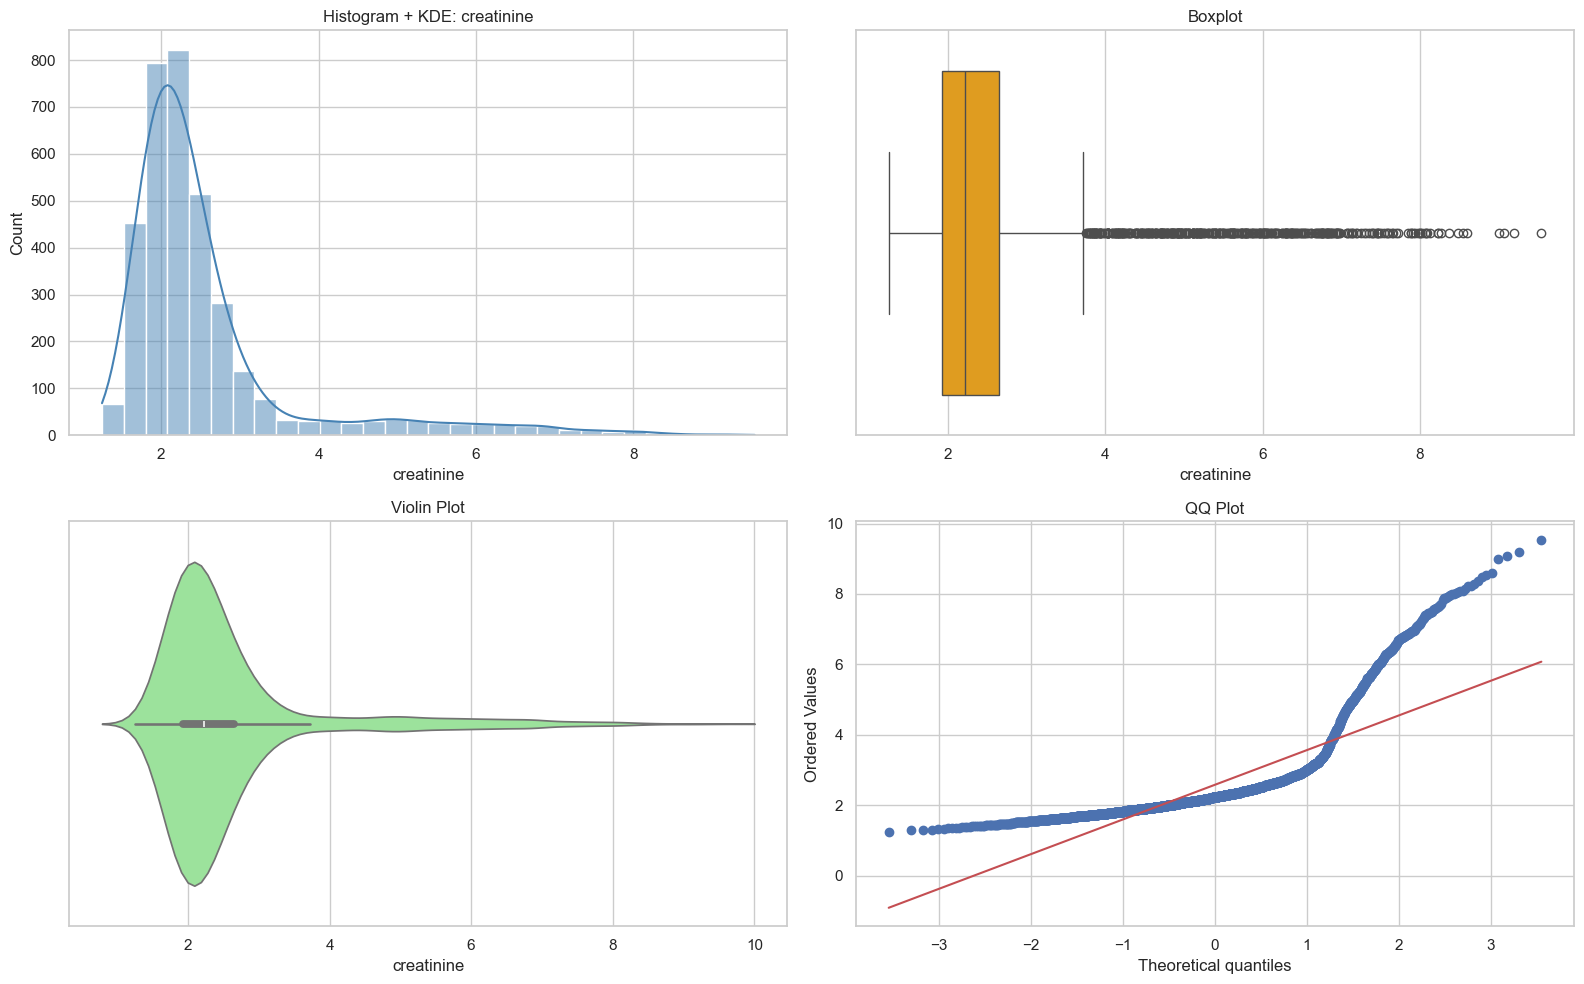

{'count': 3557,
 'mean': 2.5815350014056793,
 'median': 2.22,
 'std': 1.1920866302398978,
 'min': 1.25,
 'max': 9.54,
 'skewness': 2.5824198466152324,
 'kurtosis': 7.005883144241775,
 'normality_p_value': 0.0,
 'skew_interpretation': 'right_skewed',
 'kurtosis_interpretation': 'heavy_tails',
 'normality_interpretation': 'not_normal'}

In [21]:
nl.analyze_numeric_distribution(df = train , column = 'creatinine')

In [22]:
train , imputer1 =nl.clean_column(
    df=train,
    column='creatinine',
    method='simple',
    strategy='median',
    phase = 'fit'
)

In [23]:
train =nl.clean_column(
    df=train,
    column='creatinine',
    method='simple',
    strategy='median',
    phase = 'fit_transform'
)

In [24]:
test =nl.clean_column(
    df=test,
    column='creatinine',
    method='simple',
    strategy='median',
    phase = 'transform',
    imputer_instance=imputer1
)

In [25]:
print(nl.missing_report(df = train , column = 'creatinine'))
print(nl.missing_report(df = test , column = 'creatinine'))

{'column': 'creatinine', 'dtype': 'float64', 'total_rows': 4000, 'missing_count': 0, 'missing_percent': np.float64(0.0)}
{'column': 'creatinine', 'dtype': 'float64', 'total_rows': 1000, 'missing_count': 0, 'missing_percent': np.float64(0.0)}


#### bicarbonate

In [26]:
print(nl.missing_report(df = train , column = 'bicarbonate'))
print(nl.missing_report(df = test , column = 'bicarbonate'))

{'column': 'bicarbonate', 'dtype': 'float64', 'total_rows': 4000, 'missing_count': 396, 'missing_percent': np.float64(9.9)}
{'column': 'bicarbonate', 'dtype': 'float64', 'total_rows': 1000, 'missing_count': 115, 'missing_percent': np.float64(11.5)}


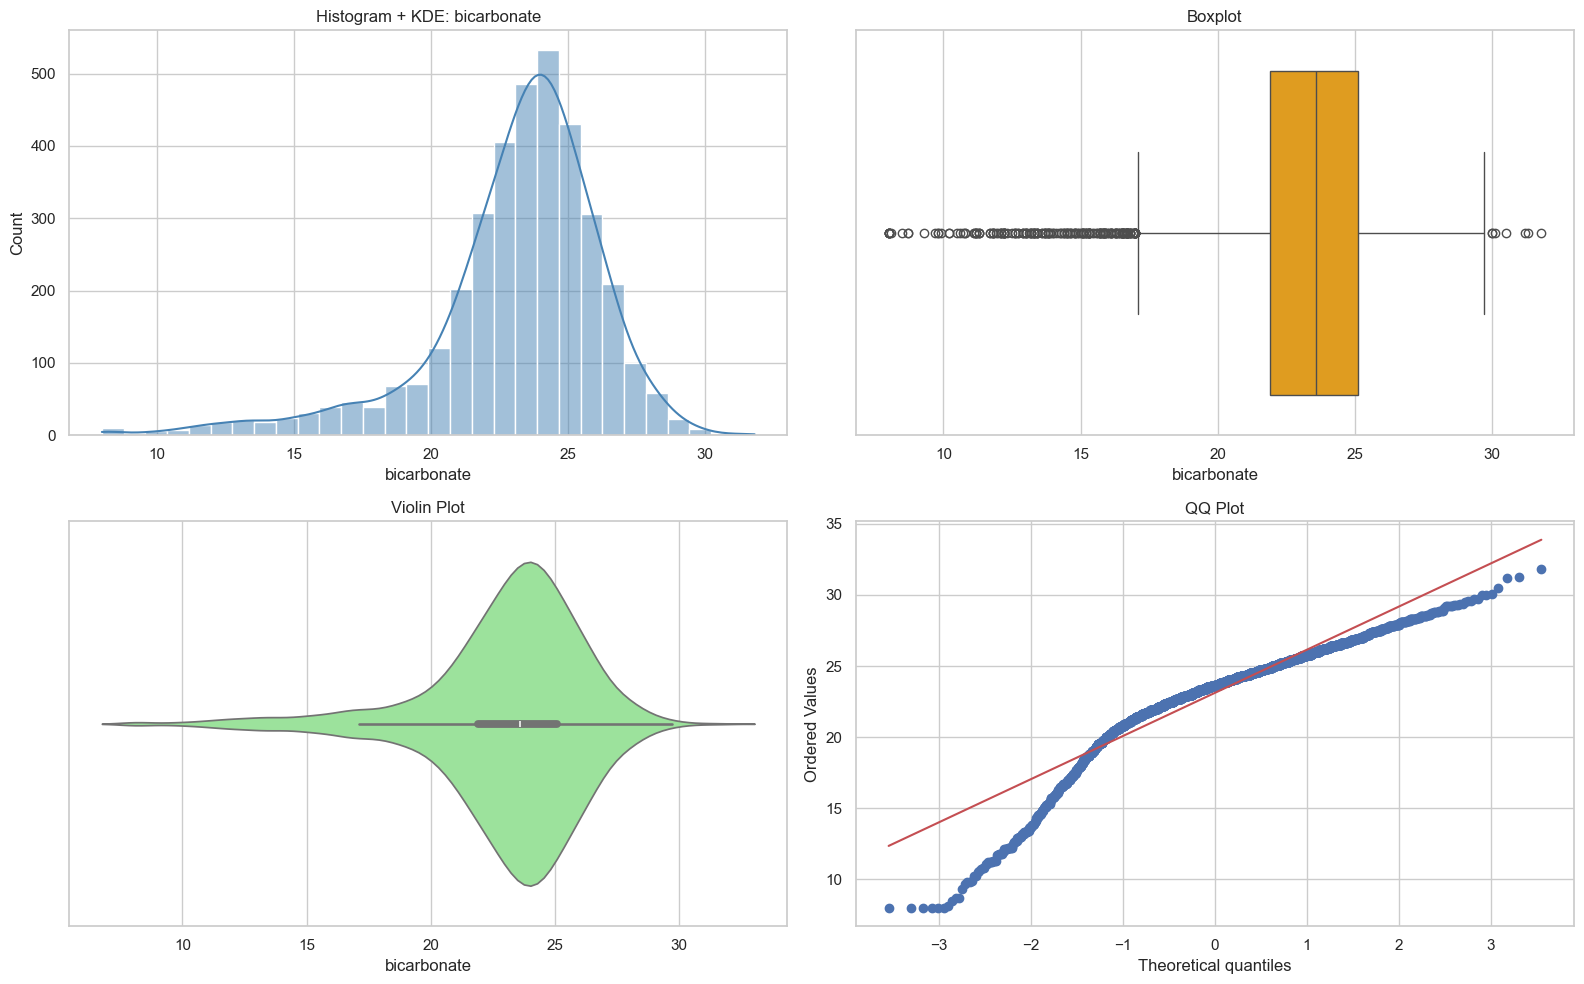

{'count': 3604,
 'mean': 23.11914539400666,
 'median': 23.6,
 'std': 3.1881876315676463,
 'min': 8.0,
 'max': 31.8,
 'skewness': -1.426621363838201,
 'kurtosis': 3.2871786928581983,
 'normality_p_value': 1.6833381432746127e-215,
 'skew_interpretation': 'left_skewed',
 'kurtosis_interpretation': 'heavy_tails',
 'normality_interpretation': 'not_normal'}

In [27]:
nl.analyze_numeric_distribution(df = train , column = 'bicarbonate')

In [28]:
train , imputer2 =nl.clean_column(
    df=train,
    column='bicarbonate',
    method='simple',
    strategy='median',
    phase = 'fit'
)

In [29]:
train =nl.clean_column(
    df=train,
    column='bicarbonate',
    method='simple',
    strategy='median',
    phase = 'fit_transform'
)

In [30]:
test =nl.clean_column(
    df=test,
    column='bicarbonate',
    method='simple',
    strategy='median',
    phase = 'transform',
    imputer_instance=imputer2
)

In [31]:
print(nl.missing_report(df = train , column = 'bicarbonate'))
print(nl.missing_report(df = test , column = 'bicarbonate'))

{'column': 'bicarbonate', 'dtype': 'float64', 'total_rows': 4000, 'missing_count': 0, 'missing_percent': np.float64(0.0)}
{'column': 'bicarbonate', 'dtype': 'float64', 'total_rows': 1000, 'missing_count': 0, 'missing_percent': np.float64(0.0)}


#### ph_arterial

In [32]:
print(nl.missing_report(df = train , column = 'ph_arterial'))
print(nl.missing_report(df = test , column = 'ph_arterial'))

{'column': 'ph_arterial', 'dtype': 'float64', 'total_rows': 4000, 'missing_count': 397, 'missing_percent': np.float64(9.93)}
{'column': 'ph_arterial', 'dtype': 'float64', 'total_rows': 1000, 'missing_count': 105, 'missing_percent': np.float64(10.5)}


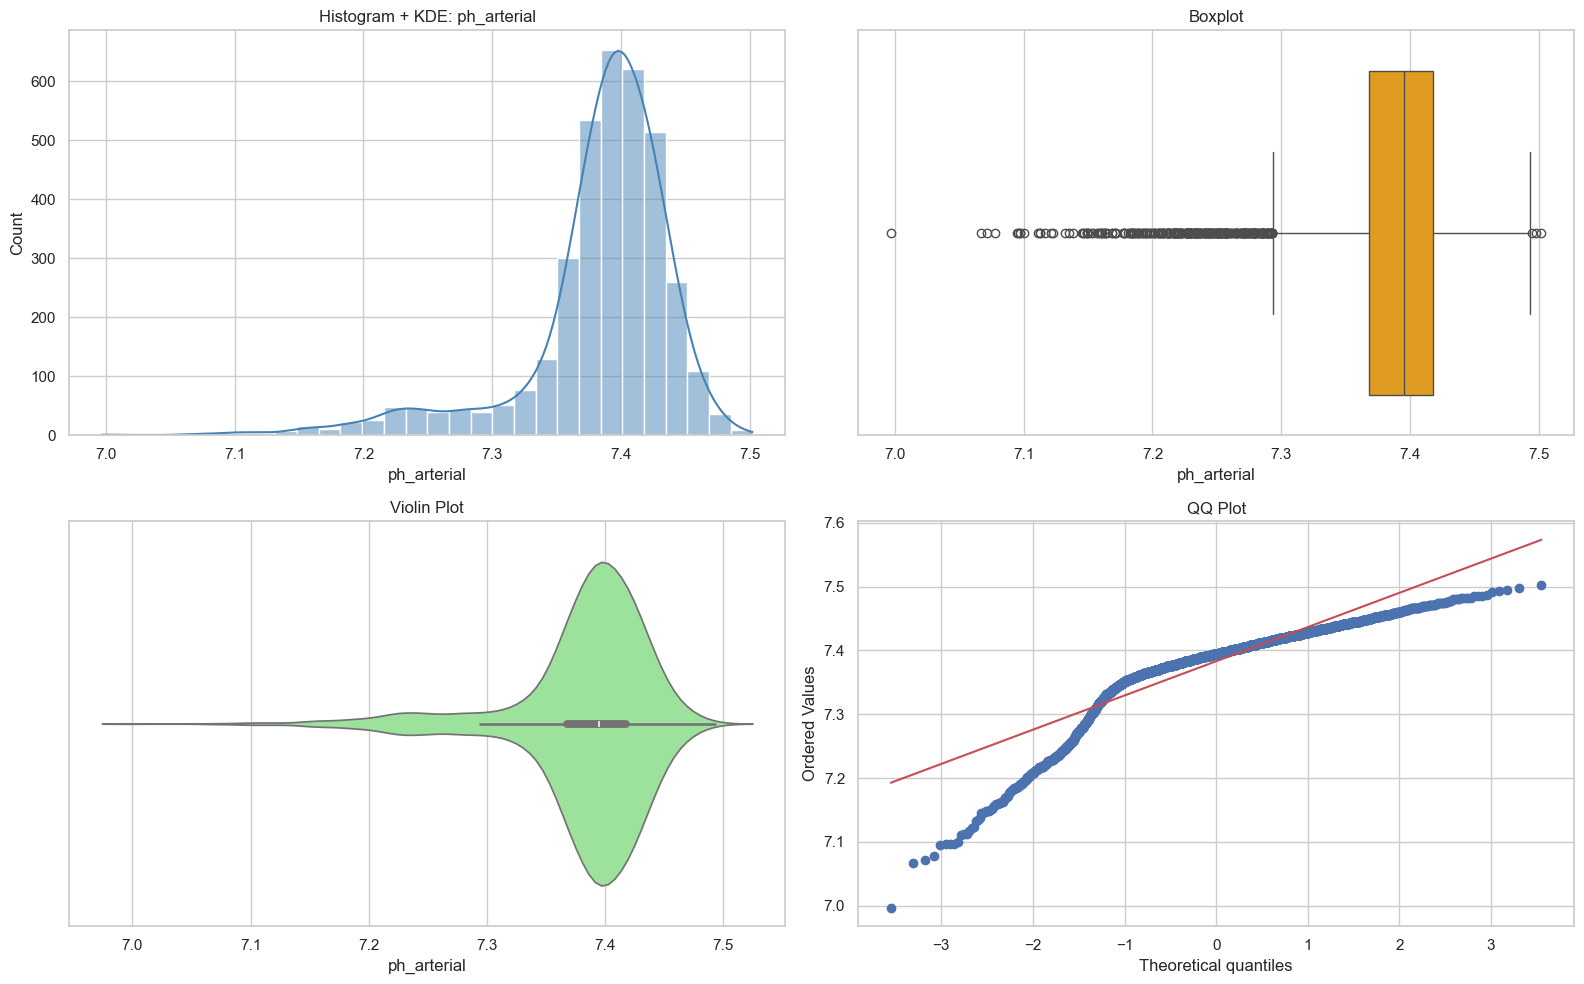

{'count': 3603,
 'mean': 7.38309214543436,
 'median': 7.395,
 'std': 0.058635714168460966,
 'min': 6.997,
 'max': 7.502,
 'skewness': -1.9057629815850685,
 'kurtosis': 4.866363615047505,
 'normality_p_value': 8.612505561063424e-306,
 'skew_interpretation': 'left_skewed',
 'kurtosis_interpretation': 'heavy_tails',
 'normality_interpretation': 'not_normal'}

In [33]:
nl.analyze_numeric_distribution(df = train , column = 'ph_arterial')

In [34]:
train , imputer3 =nl.clean_column(
    df=train,
    column='ph_arterial',
    method='simple',
    strategy='median',
    phase = 'fit'
)

In [35]:
train =nl.clean_column(
    df=train,
    column='ph_arterial',
    method='simple',
    strategy='median',
    phase = 'fit_transform'
)

In [36]:
test =nl.clean_column(
    df=test,
    column='ph_arterial',
    method='simple',
    strategy='median',
    phase = 'transform',
    imputer_instance=imputer3
)

In [37]:
print(nl.missing_report(df = train , column = 'ph_arterial'))
print(nl.missing_report(df = test , column = 'ph_arterial'))

{'column': 'ph_arterial', 'dtype': 'float64', 'total_rows': 4000, 'missing_count': 0, 'missing_percent': np.float64(0.0)}
{'column': 'ph_arterial', 'dtype': 'float64', 'total_rows': 1000, 'missing_count': 0, 'missing_percent': np.float64(0.0)}


In [38]:
train.dtypes

pao2_fio2_ratio          float64
creatinine               float64
lactate_mmol             float64
sofa_score                 int64
spo2_mean                float64
fluids_ml_24h            float64
apache_iv                float64
sirs_criteria              int64
respiratory_rate_mean    float64
respiratory_rate_min     float64
bicarbonate              float64
ph_arterial              float64
temp_celsius_min         float64
sbp_min                  float64
gender                       str
ethnicity                    str
insurance                    str
hospital_admit_source        str
sepsis_label               int64
dtype: object

#### gender

In [39]:
train['gender']

3249    F
4652    F
1364    F
1625    M
712     M
       ..
3402    M
1390    M
3095    M
4805    F
4394    M
Name: gender, Length: 4000, dtype: str

In [40]:
train['gender'].value_counts()

gender
M       2258
F       1741
Mael       1
Name: count, dtype: int64

In [41]:
nl.smart_dtype_converter(df=train , column='gender',target_type='string' ,value_map={'Mael':1 ,'M':1 ,'F':0} ,inplace=True)

✅ Conversion completed.
New dtype: string


,pao2_fio2_ratio,creatinine,lactate_mmol,sofa_score,spo2_mean,fluids_ml_24h,apache_iv,sirs_criteria,respiratory_rate_mean,respiratory_rate_min,bicarbonate,ph_arterial,temp_celsius_min,sbp_min,gender,ethnicity,insurance,hospital_admit_source,sepsis_label
3249,99.0,1.70,1.08,7,99.0,1208.0,21.8,1,20.0,16.0,23.6,7.423,36.6,101.6,0,White,Private,Direct,0
4652,98.1,1.75,0.85,7,98.1,1765.0,30.4,1,18.0,14.0,23.8,7.395,37.6,98.8,0,White,Medicare,ED,0
1364,98.7,2.27,0.81,9,98.7,1344.0,36.8,0,14.0,12.0,25.6,7.428,37.8,97.1,0,White,Medicare,ED,0
1625,95.0,2.63,0.79,9,95.0,1226.0,46.9,1,13.0,9.0,25.3,7.420,36.9,112.7,1,White,Medicare,Transfer,0
712,98.4,2.18,0.69,8,98.4,1423.0,31.6,1,14.0,10.0,26.6,7.414,36.9,116.5,1,Asian,Private,Direct,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3402,96.2,1.76,1.00,7,96.2,1921.0,32.8,0,12.0,10.0,22.8,7.422,37.0,125.5,1,White,Medicare,Transfer,0
1390,53.3,6.05,2.00,14,88.9,3325.0,60.1,3,18.0,16.0,23.5,7.293,38.1,91.9,1,White,Medicaid,ED,1
3095,94.7,2.15,0.68,8,94.7,630.0,51.0,0,14.0,12.0,24.3,7.466,36.6,121.6,1,White,Medicaid,OR,0
4805,99.0,1.89,1.11,6,99.0,1443.0,14.3,0,15.0,13.0,22.8,7.395,35.8,128.1,0,White,Medicare,OR,0


In [42]:
nl.smart_dtype_converter(df=test , column='gender',target_type='string' ,value_map={'Mael':1 ,'M':1 ,'F':0} ,inplace=True)

✅ Conversion completed.
New dtype: string


,subject_id,age,gender,weight_kg,height_cm,bmi,ethnicity,insurance,hr_mean,hr_max,...,apache_iv,qsofa,sirs_criteria,gcs_total,icu_los_hours,hospital_admit_source,icu_admit_time_hour,day_of_week,readmission_30day,sepsis_label
3706,56265,57,1,65.8,174.7,21.6,Black,Medicaid,190.4,111.5,...,28.9,1,1,9,111.4,OR,7,2,0,0
1749,60578,80,0,78.2,176.1,25.2,Asian,Medicare,68.1,83.9,...,49.0,1,0,11,60.8,ED,13,1,0,0
2217,65115,64,1,64.8,168.9,22.7,White,Self-pay,120.5,131.3,...,74.0,1,2,12,43.4,ED,23,4,0,1
11,43470,58,0,75.4,167.7,26.8,White,Private,85.6,98.8,...,48.7,1,0,7,40.2,ED,8,2,0,0
442,51015,33,0,81.1,171.7,27.5,White,Medicaid,95.1,111.1,...,33.1,1,1,9,38.9,ED,23,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2675,71076,35,1,69.3,163.7,25.8,Hispanic,Private,122.8,129.0,...,18.1,1,1,9,59.9,ED,3,5,0,0
4950,59147,68,0,81.5,169.5,28.4,Black,Self-pay,79.3,87.6,...,40.1,1,1,6,12.0,OR,21,7,0,0
2712,71889,72,0,74.4,171.0,25.4,Black,Medicare,86.9,101.1,...,31.3,1,0,6,55.8,ED,12,4,0,0
150,59023,68,0,88.3,177.3,28.1,White,Medicare,99.5,109.1,...,38.3,1,1,7,22.9,ED,14,3,0,0


In [43]:
train['gender'] = train['gender'].astype(np.int64)

In [44]:
test['gender'] = test['gender'].astype(np.int64)

#### ethnicity

In [45]:
train['ethnicity']

3249    White
4652    White
1364    White
1625    White
712     Asian
        ...  
3402    White
1390    White
3095    White
4805    White
4394    Other
Name: ethnicity, Length: 4000, dtype: str

In [46]:
train['ethnicity'].value_counts()

ethnicity
White       2377
Black        628
Hispanic     470
Asian        323
Other        202
Name: count, dtype: int64

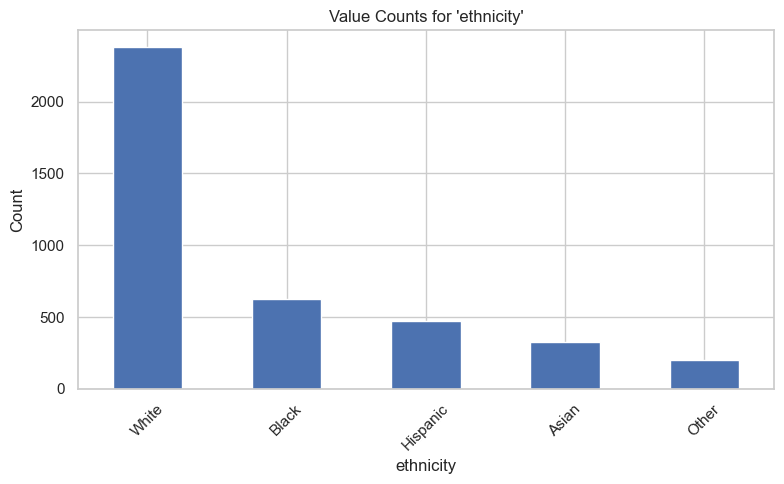

ethnicity
White       2377
Black        628
Hispanic     470
Asian        323
Other        202
Name: count, dtype: int64

In [47]:
nl.value_counts_plot(df = train , column = 'ethnicity')

In [48]:
train = nl.encode_categorical_features(df=train ,  columns='ethnicity' , encoding='onehot',drop_original=True)

In [49]:
test = nl.encode_categorical_features(df=test ,  columns='ethnicity' , encoding='onehot',drop_original=True)

In [50]:
train.head()

,pao2_fio2_ratio,creatinine,lactate_mmol,sofa_score,spo2_mean,fluids_ml_24h,apache_iv,sirs_criteria,respiratory_rate_mean,respiratory_rate_min,...,sbp_min,gender,insurance,hospital_admit_source,sepsis_label,ethnicity_Asian,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White
3249,99.0,1.70,1.08,7,99.0,1208.0,21.8,1,20.0,16.0,...,101.6,0,Private,Direct,0,False,False,False,False,True
4652,98.1,1.75,0.85,7,98.1,1765.0,30.4,1,18.0,14.0,...,98.8,0,Medicare,ED,0,False,False,False,False,True
1364,98.7,2.27,0.81,9,98.7,1344.0,36.8,0,14.0,12.0,...,97.1,0,Medicare,ED,0,False,False,False,False,True
1625,95.0,2.63,0.79,9,95.0,1226.0,46.9,1,13.0,9.0,...,112.7,1,Medicare,Transfer,0,False,False,False,False,True
712,98.4,2.18,0.69,8,98.4,1423.0,31.6,1,14.0,10.0,...,116.5,1,Private,Direct,0,True,False,False,False,False


#### insurance 

In [51]:
train['insurance']

3249     Private
4652    Medicare
1364    Medicare
1625    Medicare
712      Private
          ...   
3402    Medicare
1390    Medicaid
3095    Medicaid
4805    Medicare
4394    Medicare
Name: insurance, Length: 4000, dtype: str

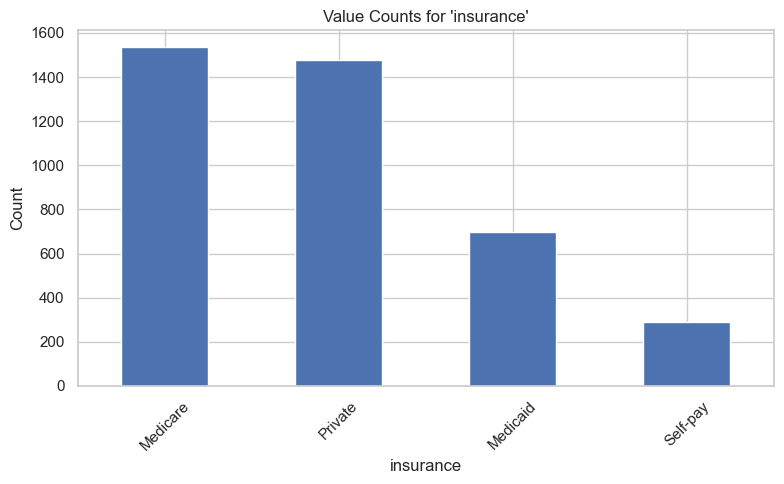

insurance
Medicare    1535
Private     1479
Medicaid     698
Self-pay     288
Name: count, dtype: int64

In [52]:
nl.value_counts_plot(df = train , column = 'insurance')

In [53]:
train = nl.encode_categorical_features(df=train ,  columns='insurance' , encoding='onehot',drop_original=True)

In [54]:
test = nl.encode_categorical_features(df=test ,  columns='insurance' , encoding='onehot',drop_original=True)

#### hospital_admit_source

In [55]:
train['hospital_admit_source']

3249      Direct
4652          ED
1364          ED
1625    Transfer
712       Direct
          ...   
3402    Transfer
1390          ED
3095          OR
4805          OR
4394          ED
Name: hospital_admit_source, Length: 4000, dtype: str

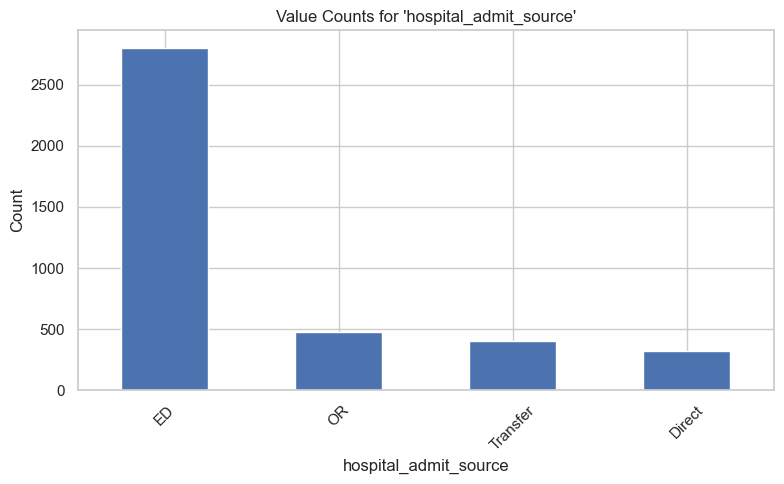

hospital_admit_source
ED          2804
OR           478
Transfer     400
Direct       318
Name: count, dtype: int64

In [56]:
nl.value_counts_plot(df = train , column = 'hospital_admit_source')

In [57]:
train = nl.encode_categorical_features(df=train ,  columns='hospital_admit_source' , encoding='onehot',drop_original=True)

In [58]:
test = nl.encode_categorical_features(df=test ,  columns='hospital_admit_source' , encoding='onehot',drop_original=True)

In [59]:
train.dtypes

pao2_fio2_ratio                   float64
creatinine                        float64
lactate_mmol                      float64
sofa_score                          int64
spo2_mean                         float64
fluids_ml_24h                     float64
apache_iv                         float64
sirs_criteria                       int64
respiratory_rate_mean             float64
respiratory_rate_min              float64
bicarbonate                       float64
ph_arterial                       float64
temp_celsius_min                  float64
sbp_min                           float64
gender                              int64
sepsis_label                        int64
ethnicity_Asian                      bool
ethnicity_Black                      bool
ethnicity_Hispanic                   bool
ethnicity_Other                      bool
ethnicity_White                      bool
insurance_Medicaid                   bool
insurance_Medicare                   bool
insurance_Private                 

In [60]:
complet_report2 , general_report2 , _ = nl.xgboost_feature_analysis(
    df = train,
    target = 'sepsis_label',
    problem_type = 'classification',
    random_state = 42,
    top_k = 35
)

In [61]:
complet_report2

,feature,gain_percent,perm_percent,combined_score
0,pao2_fio2_ratio,16.222250,100.0,49.733350
1,lactate_mmol,39.748865,0.0,23.849319
2,apache_iv,14.253358,0.0,8.552015
3,ph_arterial,12.128586,0.0,7.277151
4,creatinine,6.763609,0.0,4.058165
5,spo2_mean,4.146034,0.0,2.487621
6,sofa_score,2.928835,0.0,1.757301
7,fluids_ml_24h,1.204224,0.0,0.722534
8,respiratory_rate_min,0.917846,0.0,0.550707
9,bicarbonate,0.556950,0.0,0.334170


In [62]:
selected_features = [
    'pao2_fio2_ratio',
    'lactate_mmol',
    'apache_iv',
    'ph_arterial',
    'creatinine',
    'spo2_mean',
    'sofa_score',
    'fluids_ml_24h',
    'respiratory_rate_min',
    'bicarbonate',
    'sirs_criteria',
    'respiratory_rate_mean',
    'temp_celsius_min',
    'sepsis_label'
]

In [63]:
train = train[selected_features]
test = test[selected_features]

In [64]:
train

,pao2_fio2_ratio,lactate_mmol,apache_iv,ph_arterial,creatinine,spo2_mean,sofa_score,fluids_ml_24h,respiratory_rate_min,bicarbonate,sirs_criteria,respiratory_rate_mean,temp_celsius_min,sepsis_label
3249,99.0,1.08,21.8,7.423,1.70,99.0,7,1208.0,16.0,23.6,1,20.0,36.6,0
4652,98.1,0.85,30.4,7.395,1.75,98.1,7,1765.0,14.0,23.8,1,18.0,37.6,0
1364,98.7,0.81,36.8,7.428,2.27,98.7,9,1344.0,12.0,25.6,0,14.0,37.8,0
1625,95.0,0.79,46.9,7.420,2.63,95.0,9,1226.0,9.0,25.3,1,13.0,36.9,0
712,98.4,0.69,31.6,7.414,2.18,98.4,8,1423.0,10.0,26.6,1,14.0,36.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3402,96.2,1.00,32.8,7.422,1.76,96.2,7,1921.0,10.0,22.8,0,12.0,37.0,0
1390,53.3,2.00,60.1,7.293,6.05,88.9,14,3325.0,16.0,23.5,3,18.0,38.1,1
3095,94.7,0.68,51.0,7.466,2.15,94.7,8,630.0,12.0,24.3,0,14.0,36.6,0
4805,99.0,1.11,14.3,7.395,1.89,99.0,6,1443.0,13.0,22.8,0,15.0,35.8,0


In [65]:
train.to_csv('train.csv', index=False)

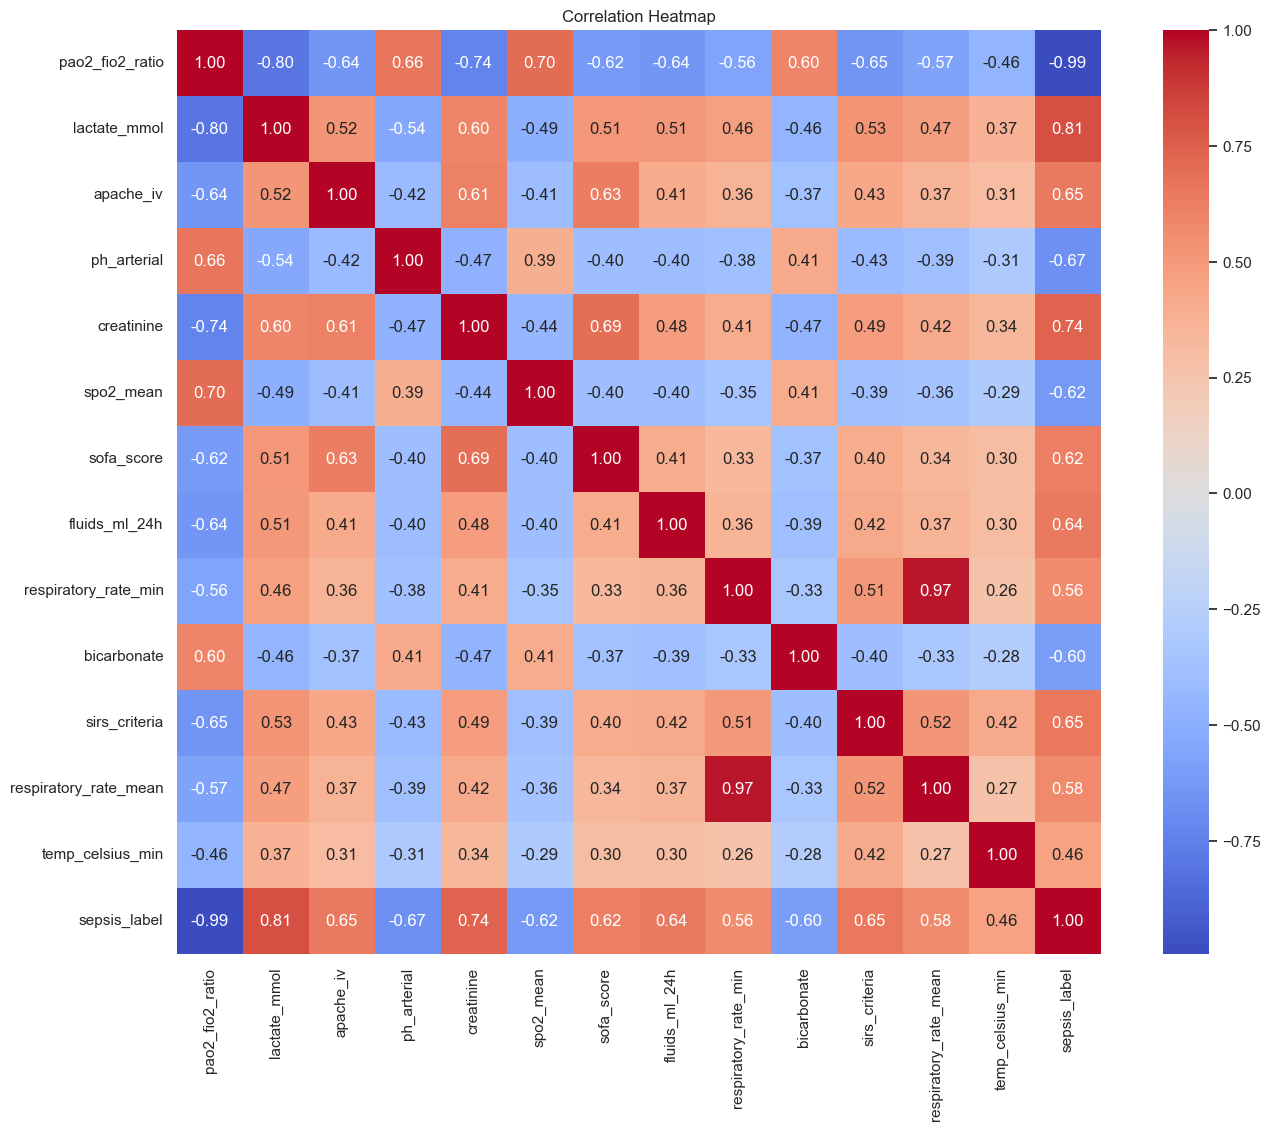

In [66]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,     
    fmt=".2f",       
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Heatmap")
plt.show()

In [67]:
selected_features = [
    'lactate_mmol',
    'apache_iv',
    'ph_arterial',
    'creatinine',
    'spo2_mean',
    'sofa_score',
    'fluids_ml_24h',
    'respiratory_rate_min',
    'bicarbonate',
    'sirs_criteria',
    'temp_celsius_min',
    'sepsis_label'
]

In [68]:
train = train[selected_features]
test = test[selected_features]

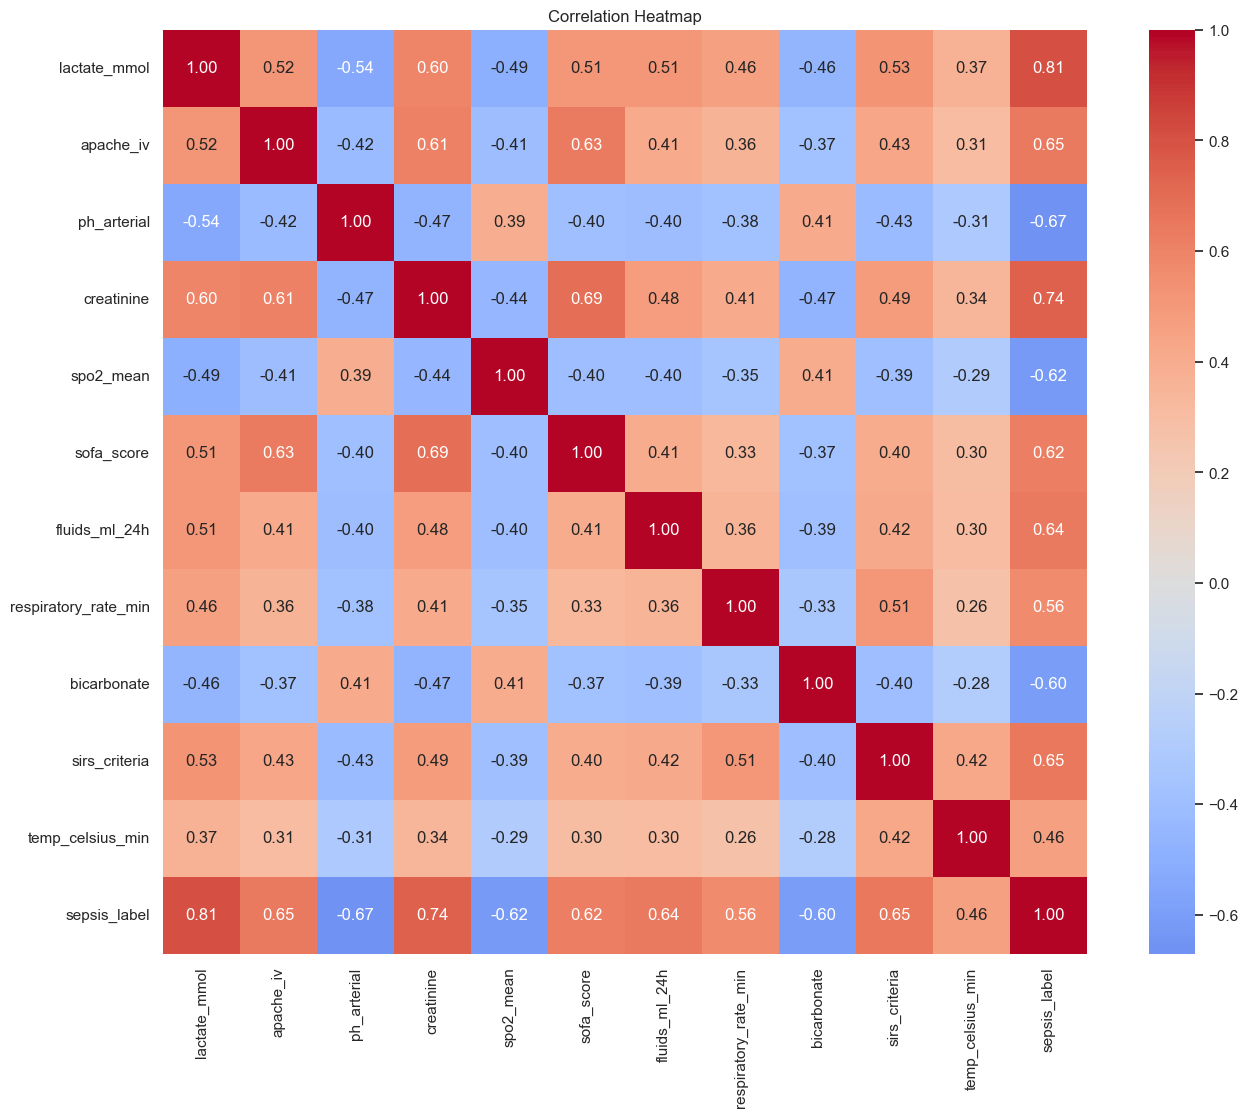

In [69]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,     
    fmt=".2f",       
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Heatmap")
plt.show()

In [70]:
train.to_csv('train.csv', index=False)

In [71]:
X_train = train.drop('sepsis_label', axis=1)
y_train = train['sepsis_label']

X_test = test.drop('sepsis_label', axis=1)
y_test = test['sepsis_label']

In [72]:
model = AdaBoostClassifier(
    estimator=RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    random_state=42
)

In [73]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'estimator__max_depth': [1, 3, 5],
    'estimator__min_samples_split': [2, 5, 10]
}

In [74]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [75]:
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__max_depth': [1, 3, ...], 'estimator__min_samples_split': [2, 5, ...], 'learning_rate': [0.01, 0.1], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :re

In [76]:
grid_search.best_params_

{'estimator__max_depth': 3,
 'estimator__min_samples_split': 2,
 'learning_rate': 0.01,
 'n_estimators': 100}

In [77]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

In [78]:
model = AdaBoostClassifier(
    estimator=RandomForestClassifier(
        n_estimators=100,
        max_depth=3,
        min_samples_split=2,
        random_state=42
    ),
    n_estimators=100,
    learning_rate=0.01,
    random_state=42
)

In [79]:
model.fit(X_train, y_train, sample_weight=sample_weights)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",RandomForestC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.01
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,RandomForestClassifier,RandomForestC...ndom_state=42)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](100,)","[0.,0.,0.,...,1.,1.,1.]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[0.06,0.07,0.07,...,0. ,0. ,0. ]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[RandomForestC...te=1608637542), RandomForestC...te=1273642419), RandomForestC...te=1935803228), RandomForestC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](11,)","[0.39,0.08,0.07,...,0.01,0.08,0. ]"


In [80]:
y_pred = model.predict(X_test)

c:\users\navid\src\navilib\NaviLib\evaluation.py:423: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


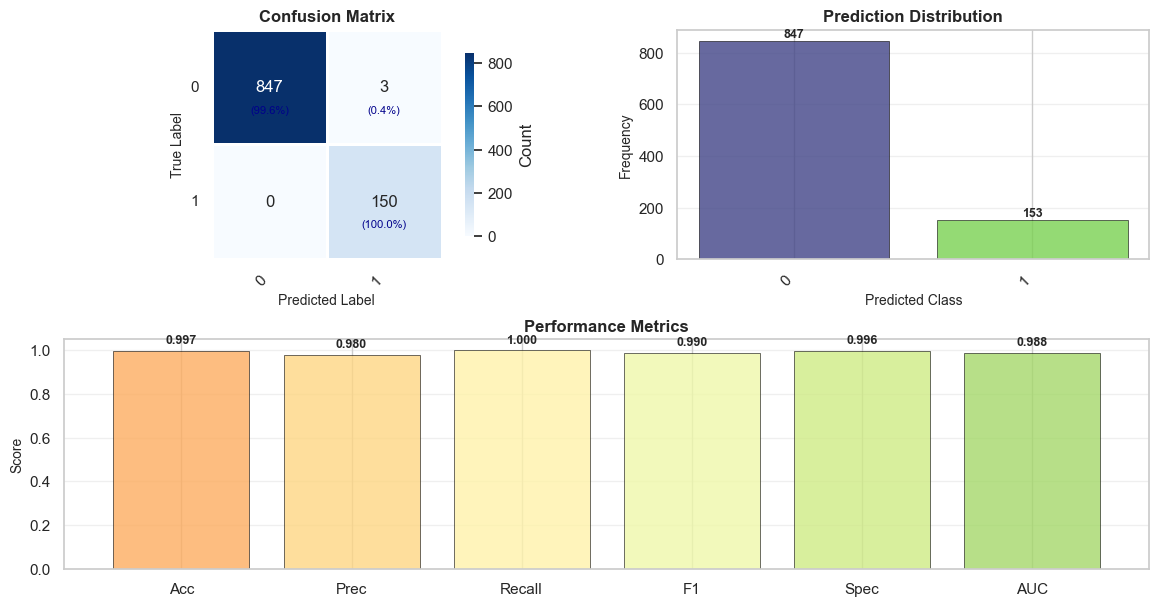

{'accuracy': 0.997,
 'precision_macro': 0.9901960784313726,
 'recall_macro': 0.9982352941176471,
 'f1_macro': 0.9941655921632233,
 'precision_weighted': 0.9970588235294117,
 'recall_weighted': 0.997,
 'f1_weighted': 0.9970121997467867,
 'kappa': 0.9883313885647608,
 'mcc': 0.9883986793042009,
 'precision_0': np.float64(1.0),
 'recall_0': np.float64(0.9964705882352941),
 'f1_0': np.float64(0.9982321744254566),
 'precision_1': np.float64(0.9803921568627451),
 'recall_1': np.float64(1.0),
 'f1_1': np.float64(0.9900990099009901),
 'precision_positive': 0.9803921568627451,
 'recall_positive': 1.0,
 'f1_positive': 0.9900990099009901,
 'specificity': 0.9964705882352941}

In [81]:
nl.evaluate_classification_model(y_true=y_test , y_pred=y_pred )

In [82]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train:", train_score)
print("Test :", test_score)

Train: 0.999
Test : 0.997


In [83]:
print(grid_search.best_score_)

1.0


In [84]:
import joblib

joblib.dump(model, 'golden_treatment_model.pkl')

['golden_treatment_model.pkl']